In [49]:
# Cell 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sqlalchemy import create_engine

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [50]:
# Cell 2: Load Dataset
df = pd.read_csv('../data/superstore.csv', encoding='latin-1')

print("✅ Dataset Loaded Successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names:")
print(df.columns.tolist())
df.head()

✅ Dataset Loaded Successfully!
Shape: 9994 rows × 21 columns

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [51]:
# Cell 3: Explore Dataset
print("="*60)
print("DATASET INFO")
print("="*60)
df.info()

print("\n" + "="*60)
print("MISSING VALUES PER COLUMN")
print("="*60)
print(df.isnull().sum())

print("\n" + "="*60)
print("DUPLICATE ROWS")
print("="*60)
print(f"Total duplicates: {df.duplicated().sum()}")

print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)
df.describe()

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quanti

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [52]:
# Cell 4: Handle Missing Values
print("BEFORE Cleaning - Missing values:")
print(df.isnull().sum().sum(), "total missing values")
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"✅ Filled '{col}' with median: {median_val}")

object_cols = df.select_dtypes(include=['str']).columns.tolist()
for col in object_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"✅ Filled '{col}' with mode: {mode_val}")

print(f"\nAFTER Cleaning - Missing values: {df.isnull().sum().sum()}")

BEFORE Cleaning - Missing values:
0 total missing values

AFTER Cleaning - Missing values: 0


In [53]:
# Cell 4: Handle Missing Values
print("BEFORE Cleaning - Missing values:")
print(df.isnull().sum().sum(), "total missing values")

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"✅ Filled '{col}' with median: {median_val}")

object_cols = df.select_dtypes(include=['str']).columns.tolist()
for col in object_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"✅ Filled '{col}' with mode: {mode_val}")

print(f"\nAFTER Cleaning - Missing values: {df.isnull().sum().sum()}")

BEFORE Cleaning - Missing values:
0 total missing values

AFTER Cleaning - Missing values: 0


In [54]:
# Cell 6: Fix Data Types

date_columns = ['Order Date', 'Ship Date']
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=False)
        print(f"✅ '{col}' converted to datetime")

category_columns = ['Ship Mode', 'Segment', 'Country', 'Region', 
                    'Category', 'Sub-Category']
for col in category_columns:
    if col in df.columns:
        df[col] = df[col].astype('category')
        print(f"✅ '{col}' converted to category")

print("\nUpdated Data Types:")
print(df.dtypes)

✅ 'Order Date' converted to datetime
✅ 'Ship Date' converted to datetime
✅ 'Ship Mode' converted to category
✅ 'Segment' converted to category
✅ 'Country' converted to category
✅ 'Region' converted to category
✅ 'Category' converted to category
✅ 'Sub-Category' converted to category

Updated Data Types:
Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode              category
Customer ID                 str
Customer Name               str
Segment                category
Country                category
City                        str
State                       str
Postal Code               int64
Region                 category
Product ID                  str
Category               category
Sub-Category           category
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


In [55]:
# Cell 7: Handle Outliers using IQR Method
def remove_outliers_iqr(data, column):
    """Remove outliers using Inter-Quartile Range method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    before = len(data)
    data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    after = len(data)
    
    print(f"'{column}': Removed {before - after} outliers "
          f"(Range: {lower_bound:.2f} to {upper_bound:.2f})")
    return data

outlier_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
print("Removing Outliers:\n")
for col in outlier_cols:
    if col in df.columns:
        df = remove_outliers_iqr(df, col)

df = df.reset_index(drop=True)
print(f"\n✅ Final dataset shape: {df.shape}")

Removing Outliers:

'Sales': Removed 1167 outliers (Range: -271.71 to 498.93)
'Quantity': Removed 122 outliers (Range: -2.50 to 9.50)
'Discount': Removed 817 outliers (Range: -0.30 to 0.50)
'Profit': Removed 1124 outliers (Range: -26.90 to 53.31)

✅ Final dataset shape: (6764, 21)


In [56]:
# Cell 8: Save Cleaned Dataset
df.to_csv('../data/cleaned_superstore.csv', index=False)
print("✅ Cleaned dataset saved to: data/cleaned_superstore.csv")
print(f"Final Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

✅ Cleaned dataset saved to: data/cleaned_superstore.csv
Final Shape: 6764 rows × 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136
1,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
2,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164
3,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694
4,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656


In [57]:
# Cell 9: Statistical Summary
print("="*60)
print("📊 NUMERICAL STATISTICS")
print("="*60)
print(df.describe())

print("\n" + "="*60)
print("📋 DATASET INFO")
print("="*60)
df.info()

print("\n" + "="*60)
print("📈 CATEGORICAL VALUE COUNTS")
print("="*60)
cat_cols = df.select_dtypes(include='category').columns
for col in cat_cols[:3]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

📊 NUMERICAL STATISTICS
            Row ID                  Order Date                   Ship Date  \
count  6764.000000                        6764                        6764   
mean   4991.223389  2016-05-02 00:51:18.415139  2016-05-06 00:04:53.790656   
min       1.000000         2014-01-03 00:00:00         2014-01-07 00:00:00   
25%    2495.750000         2015-05-25 00:00:00         2015-05-28 00:00:00   
50%    5019.000000         2016-07-02 12:00:00         2016-07-04 00:00:00   
75%    7454.250000         2017-05-15 00:00:00         2017-05-19 06:00:00   
max    9993.000000         2017-12-30 00:00:00         2018-01-05 00:00:00   
std    2881.116050                         NaN                         NaN   

        Postal Code        Sales     Quantity     Discount       Profit  
count   6764.000000  6764.000000  6764.000000  6764.000000  6764.000000  
mean   55764.750444    68.003902     3.373300     0.096273    11.669861  
min     1453.000000     0.990000     1.000000     0.

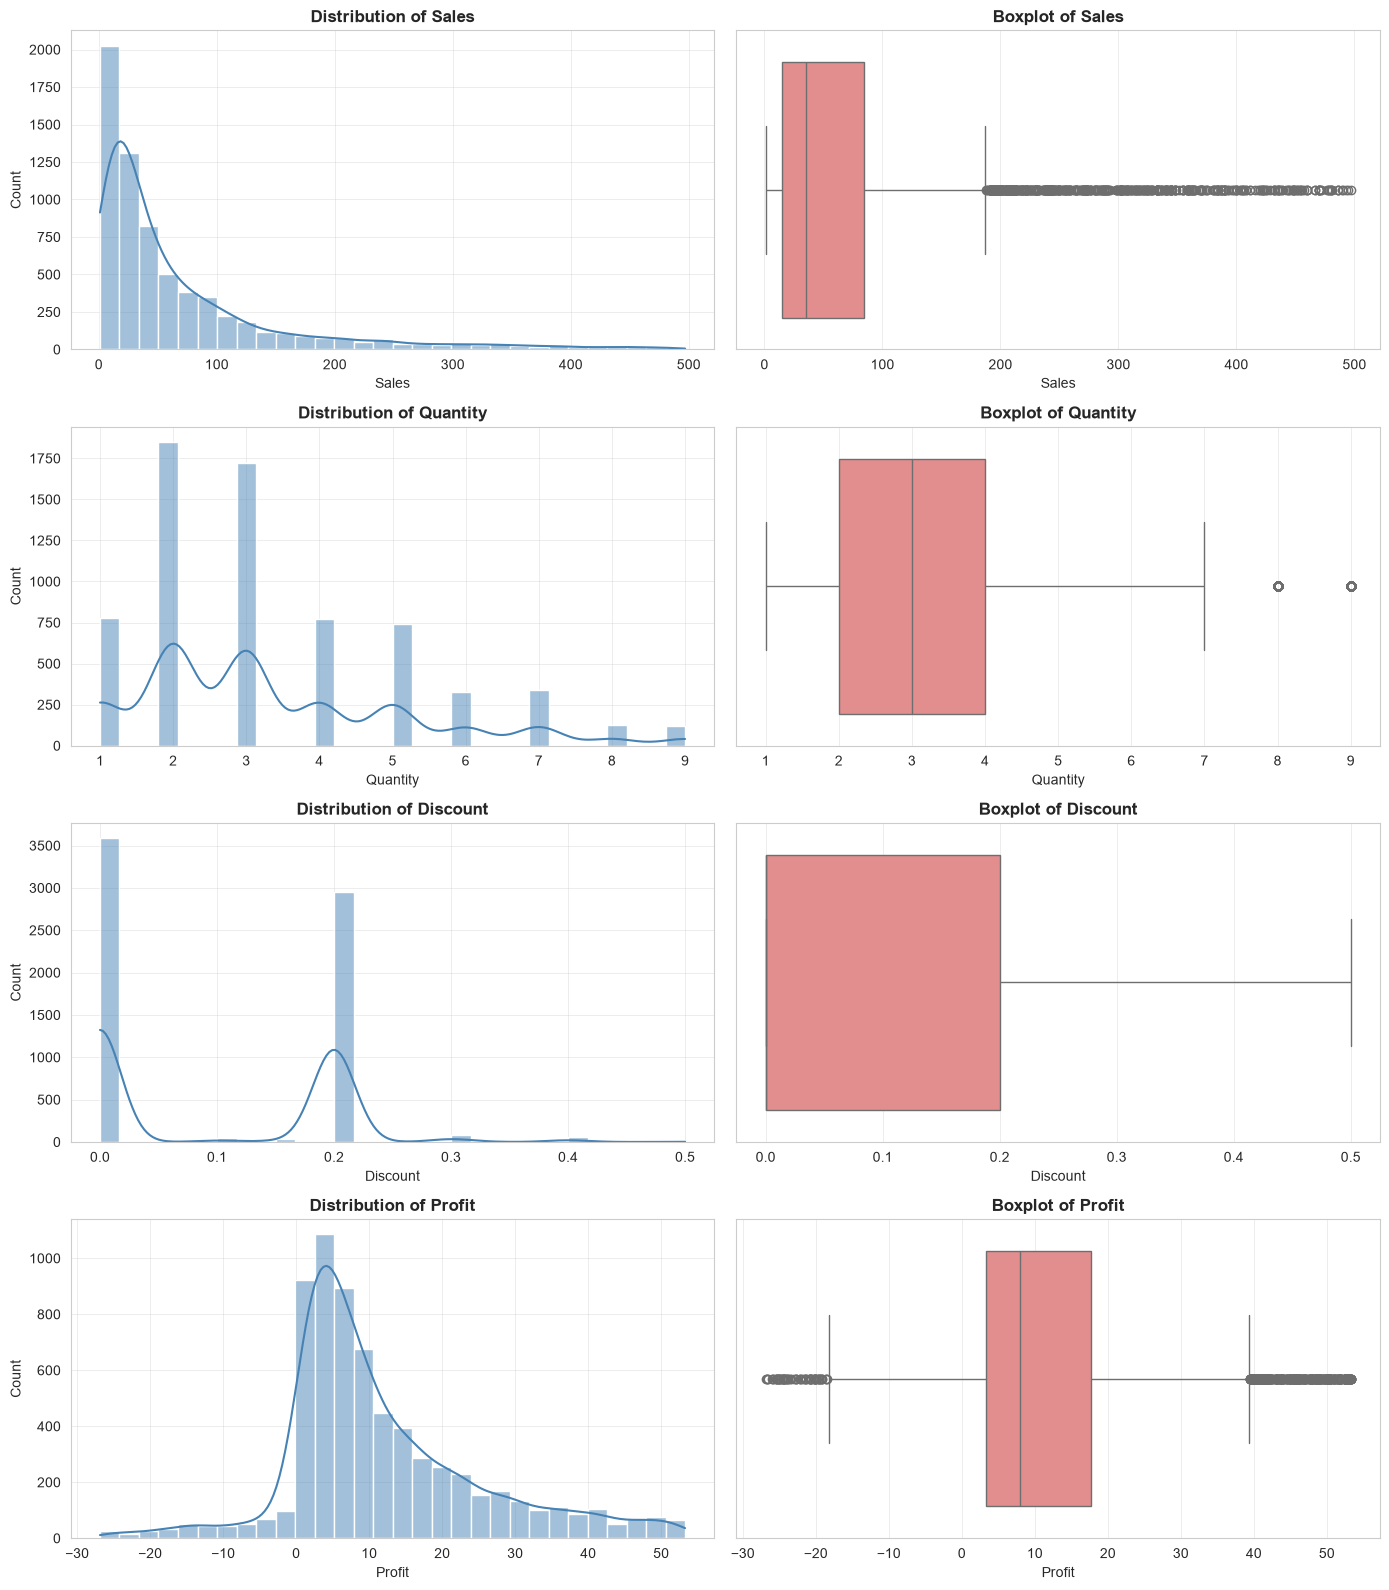

✅ Saved to reports/histograms_boxplots.png


In [58]:
# Cell 10: Histograms & Boxplots (Distributions)
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
num_cols = [col for col in num_cols if col in df.columns]

fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 4*len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, bins=30, kde=True, 
                 color='steelblue', ax=axes[i, 0])
    axes[i, 0].set_title(f'Distribution of {col}', fontweight='bold')
    sns.boxplot(data=df, x=col, color='lightcoral', ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot of {col}', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/histograms_boxplots.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Saved to reports/histograms_boxplots.png")

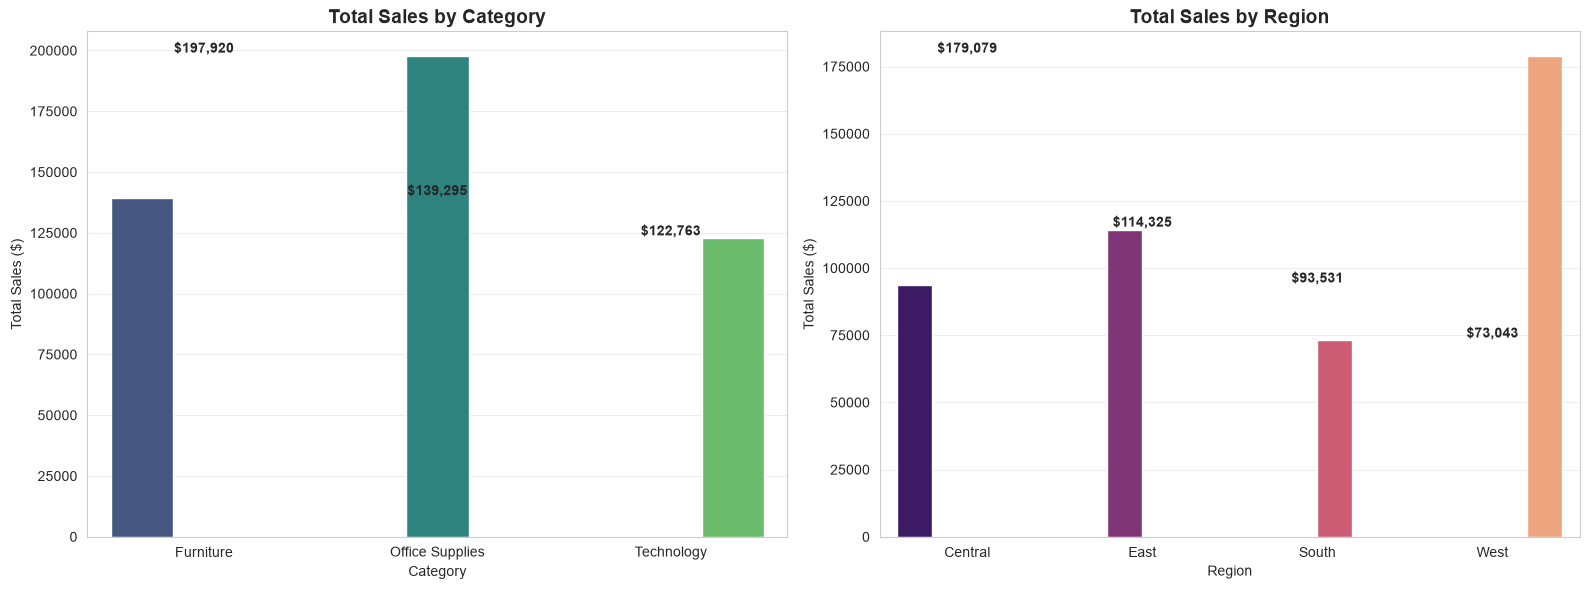

✅ Saved to reports/bar_charts.png


In [59]:
# Cell 11: Bar Charts (Categorical Comparisons)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

category_sales = df.groupby('Category', observed=True)['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.index, y=category_sales.values, 
            hue=category_sales.index, palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Total Sales by Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Sales ($)')
for i, v in enumerate(category_sales.values):
    axes[0].text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold')

region_sales = df.groupby('Region', observed=True)['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.index, y=region_sales.values, 
            hue=region_sales.index, palette='magma', legend=False, ax=axes[1])
axes[1].set_title('Total Sales by Region', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Total Sales ($)')
for i, v in enumerate(region_sales.values):
    axes[1].text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/bar_charts.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Saved to reports/bar_charts.png")

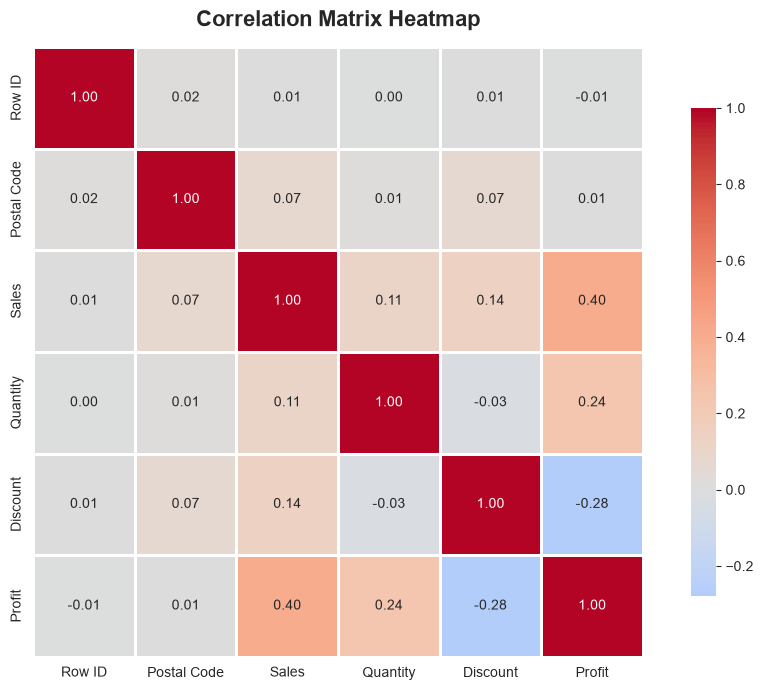

✅ Saved to reports/correlation_heatmap.png


In [60]:
# Cell 12: Correlation Heatmap
plt.figure(figsize=(10, 7))

numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f',
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Saved to reports/correlation_heatmap.png")

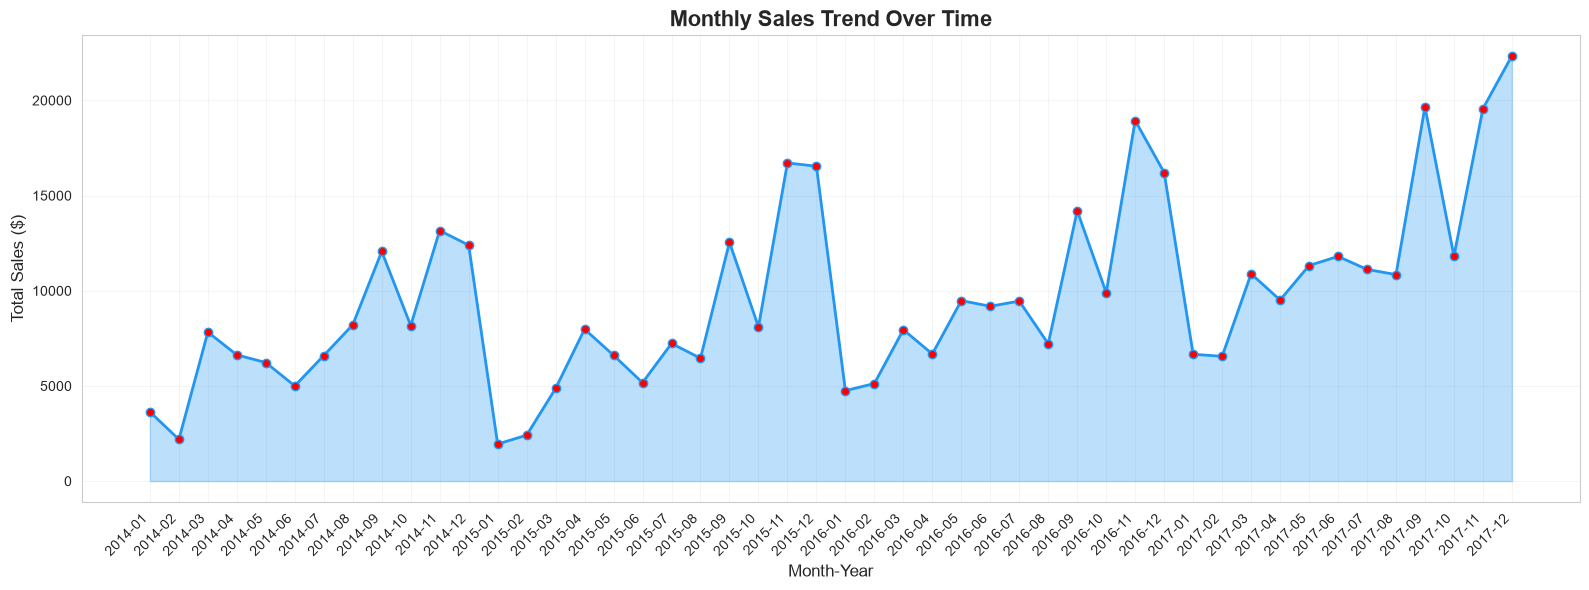

✅ Saved to reports/sales_trend.png


In [61]:
# Cell 13: Line Chart - Sales Trend Over Time
if 'Order Date' in df.columns:
    df['Year'] = df['Order Date'].dt.year
    df['Month'] = df['Order Date'].dt.month
    df['YearMonth'] = df['Order Date'].dt.to_period('M').astype(str)
    monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()
    plt.figure(figsize=(16, 6))
    plt.plot(monthly_sales['YearMonth'], monthly_sales['Sales'],
             marker='o', linewidth=2, markersize=6,
             color='#2196F3', markerfacecolor='red')
    plt.fill_between(range(len(monthly_sales)), monthly_sales['Sales'],
                     alpha=0.3, color='#2196F3')
    
    plt.title('Monthly Sales Trend Over Time', fontsize=16, fontweight='bold')
    plt.xlabel('Month-Year', fontsize=12)
    plt.ylabel('Total Sales ($)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../reports/sales_trend.png', dpi=100, bbox_inches='tight')
    plt.show()
    print("✅ Saved to reports/sales_trend.png")

In [62]:
# Cell 14: Interactive Plotly Chart
subcategory_sales = df.groupby('Sub-Category', observed=True)['Sales'].sum().reset_index()
subcategory_sales = subcategory_sales.sort_values('Sales', ascending=True)

fig = px.bar(subcategory_sales, 
             x='Sales', 
             y='Sub-Category',
             orientation='h',
             title='Total Sales by Sub-Category (Interactive)',
             color='Sales',
             color_continuous_scale='Viridis',
             text='Sales')

fig.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig.update_layout(height=600, showlegend=False)
fig.write_html('../reports/interactive_chart.html')
fig.show()
print("✅ Saved to reports/interactive_chart.html")

✅ Saved to reports/interactive_chart.html


In [63]:
# Cell 15: Save data to SQLite database using SQLAlchemy
engine = create_engine('sqlite:///../data/superstore.db')
df.to_sql('sales_data', con=engine, if_exists='replace', index=False)
test_query = pd.read_sql('SELECT COUNT(*) as total_rows FROM sales_data', con=engine)
print("✅ Data saved to SQLite database: data/superstore.db")
print(f"Total rows in database: {test_query['total_rows'][0]}")

✅ Data saved to SQLite database: data/superstore.db
Total rows in database: 6764


In [64]:
# Cell 16: 📊 5 KEY INSIGHTS
print("="*70)
print("📊 5 KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS")
print("="*70)

print("\n🔍 INSIGHT 1: Top Performing Category")
print("-"*70)
top_cat = df.groupby('Category', observed=True)['Sales'].sum().sort_values(ascending=False)
print(f"   ➤ '{top_cat.index[0]}' is the highest-selling category")
print(f"   ➤ Total Sales: ${top_cat.iloc[0]:,.2f}")
print(f"   ➤ Contributes {(top_cat.iloc[0]/top_cat.sum())*100:.1f}% of total sales")

print("\n🔍 INSIGHT 2: Best Performing Region")
print("-"*70)
top_region = df.groupby('Region', observed=True)['Sales'].sum().sort_values(ascending=False)
print(f"   ➤ '{top_region.index[0]}' region leads in sales")
print(f"   ➤ Total Sales: ${top_region.iloc[0]:,.2f}")

print("\n🔍 INSIGHT 3: Sales-Profit Correlation")
print("-"*70)
correlation = df['Sales'].corr(df['Profit'])
print(f"   ➤ Correlation between Sales and Profit: {correlation:.4f}")
if correlation > 0.5:
    print(f"   ➤ Strong POSITIVE correlation - Higher sales = Higher profit")
elif correlation > 0:
    print(f"   ➤ Weak positive correlation")
else:
    print(f"   ➤ Negative correlation - Higher sales don't guarantee profit")

print("\n🔍 INSIGHT 4: Sales Performance Statistics")
print("-"*70)
print(f"   ➤ Average Sale Value: ${df['Sales'].mean():,.2f}")
print(f"   ➤ Median Sale Value: ${df['Sales'].median():,.2f}")
print(f"   ➤ Total Revenue: ${df['Sales'].sum():,.2f}")
print(f"   ➤ Total Profit: ${df['Profit'].sum():,.2f}")

print("\n🔍 INSIGHT 5: Customer Segment Analysis")
print("-"*70)
segment_data = df.groupby('Segment', observed=True).agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).sort_values('Sales', ascending=False)
top_segment = segment_data.index[0]
print(f"   ➤ '{top_segment}' is the most valuable customer segment")
print(f"   ➤ Sales: ${segment_data.iloc[0]['Sales']:,.2f}")
print(f"   ➤ Profit: ${segment_data.iloc[0]['Profit']:,.2f}")

print("\n" + "="*70)
print("✅ EDA COMPLETE - All insights documented successfully!")
print("="*70)

📊 5 KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS

🔍 INSIGHT 1: Top Performing Category
----------------------------------------------------------------------
   ➤ 'Office Supplies' is the highest-selling category
   ➤ Total Sales: $197,919.73
   ➤ Contributes 43.0% of total sales

🔍 INSIGHT 2: Best Performing Region
----------------------------------------------------------------------
   ➤ 'West' region leads in sales
   ➤ Total Sales: $179,078.70

🔍 INSIGHT 3: Sales-Profit Correlation
----------------------------------------------------------------------
   ➤ Correlation between Sales and Profit: 0.3972
   ➤ Weak positive correlation

🔍 INSIGHT 4: Sales Performance Statistics
----------------------------------------------------------------------
   ➤ Average Sale Value: $68.00
   ➤ Median Sale Value: $34.80
   ➤ Total Revenue: $459,978.39
   ➤ Total Profit: $78,934.94

🔍 INSIGHT 5: Customer Segment Analysis
----------------------------------------------------------------------
   ➤ 'C